In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader

b = np.load('rmd17_benzene.npz')
print(b.files)
b['coords']
print(b['nuclear_charges'])

a = np.load('rmd17_ethanol.npz')
print(a['nuclear_charges'])


['nuclear_charges', 'coords', 'energies', 'forces', 'old_indices', 'old_energies', 'old_forces']
[6 6 6 6 6 6 1 1 1 1 1 1]
[6 6 8 1 1 1 1 1 1]


In [2]:
all_coords = b['coords']
all_energies = b['energies']

print(all_coords.shape)
print(all_energies.shape)

N = len(all_coords)
#np.random.seed(42)  
perm = np.random.permutation(N)

coords = all_coords[perm[:2000]]        # random 2000 selected out of the 100000
energies = all_energies[perm[:2000]]

print(coords.shape)
print(energies.shape)


(100000, 12, 3)
(100000,)
(2000, 12, 3)
(2000,)


In [3]:
bonds = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,0),(0,6),(1,7),(2,8),(3,9),(4,10),(5,11)]

def bond_lengths(coords):
    lengths = []
    for i in range(len(coords)):
        for a,b in bonds:
            length = np.linalg.norm(coords[i,a,:]-coords[i,b,:])

            lengths.append(length)
    return(lengths)

ben_lengths = np.array(bond_lengths(coords))
BL = ben_lengths.reshape(len(coords), len(bonds))
print(BL)
print(BL.shape)

[[1.41246375 1.39153237 1.39037454 ... 1.10246327 1.06408051 1.09605723]
 [1.4313645  1.38611716 1.40661361 ... 1.11402492 1.04713425 1.11719895]
 [1.36910226 1.38725124 1.42013873 ... 1.04310738 1.07433561 1.0913794 ]
 ...
 [1.43948699 1.40987105 1.46444298 ... 1.11589098 1.08567018 1.10545038]
 [1.4494806  1.46533853 1.40803551 ... 1.09225775 1.11373516 1.07451664]
 [1.37001788 1.37419649 1.40147851 ... 1.04989571 1.08516681 1.11442945]]
(2000, 12)


In [4]:
ccc = [((c-1) % 6, c, (c+1) % 6) for c in range(6)]
hcc = [(6 + c, c, (c+1) % 6) for c in range(6)]
cch = [((c-1) % 6, c, 6 + c) for c in range(6)]

angles = ccc + hcc + cch

def bond_angles(coords):
    ben_angles = []
    for o in range(len(coords)):
        for i,j,k in angles:
            length1 = np.linalg.norm(coords[o,i,:]-coords[o,j,:])
            length2 = np.linalg.norm(coords[o,k,:]-coords[o,j,:])

            dot_prod = np.dot((coords[o,i,:]-coords[o,j,:]),(coords[o,k,:]-coords[o,j,:]))

            cosang = dot_prod / (length1 * length2)

            ben_angles.append(np.acos(cosang))
    return(ben_angles)

benz_angles = np.array(bond_angles(coords))
AN = benz_angles.reshape(len(coords), len(angles))
print(AN)
print(AN.shape)


[[2.07505795 2.10844464 2.12161223 ... 1.96447038 1.9277467  2.16521893]
 [2.08161823 2.07633325 2.10335776 ... 1.97091336 2.14948381 2.12535276]
 [2.08287194 2.11522401 2.11140554 ... 1.98338667 2.10439462 2.01728133]
 ...
 [2.06091604 2.05876141 2.10788806 ... 2.09388788 2.13679241 2.12441154]
 [2.05422    2.0837531  2.05417439 ... 1.95137713 2.25278151 2.0197467 ]
 [2.09424132 2.12958914 2.0657546  ... 2.17354225 2.11319395 2.04176209]]
(2000, 18)


In [5]:
X = np.concatenate((BL,AN), axis=1)
y = np.array(energies)

print(X)
print(y)
print(X.shape)
print(y.shape)

[[1.41246375 1.39153237 1.39037454 ... 1.96447038 1.9277467  2.16521893]
 [1.4313645  1.38611716 1.40661361 ... 1.97091336 2.14948381 2.12535276]
 [1.36910226 1.38725124 1.42013873 ... 1.98338667 2.10439462 2.01728133]
 ...
 [1.43948699 1.40987105 1.46444298 ... 2.09388788 2.13679241 2.12441154]
 [1.4494806  1.46533853 1.40803551 ... 1.95137713 2.25278151 2.0197467 ]
 [1.37001788 1.37419649 1.40147851 ... 2.17354225 2.11319395 2.04176209]]
[-145427.6843322  -145431.52754274 -145431.86439487 ... -145431.19054859
 -145426.8083247  -145433.21218648]
(2000, 30)
(2000,)


In [6]:
mu_X = X.mean(axis=0)
std_X = X.std(axis=0)

X_new = (X - mu_X)/ std_X

mu_y = y.mean()
std_y = y.std()

y_new = (y - mu_y)/ std_y

print(y_new)

[ 1.53988544 -0.08264172 -0.224854   ...  0.05963052  1.90971841
 -0.79386485]


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2)

In [8]:
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)

y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

print(y_train_t.shape)

torch.Size([1600, 1])


In [9]:
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [10]:
import torch.nn as nn

In [11]:
class Model(nn.Module):
    
    def __init__(self, input_features = 30, hidden1 = 64, hidden2 = 32, hidden3 = 16, output_features = 1):
        super().__init__()
        self.fc1 = nn.Linear(input_features, hidden1) 
        self.fc2 = nn.Linear(hidden1, hidden2) 
        self.fc3 = nn.Linear(hidden2, hidden3) 
        self.fc4 = nn.Linear(hidden3, output_features)
        self.ac1 = nn.SiLU()
        self.ac2 = nn.SiLU()
        self.ac3 = nn.SiLU()

    def forward(self, x):
        x = self.fc1(x) 
        x = self.ac1(x)
        x = self.fc2(x)
        x = self.ac2(x) 
        x = self.fc3(x)
        x = self.ac3(x)
        x = self.fc4(x) 
        return x

In [12]:
epochs = 200
losses = []

model = Model()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay = 1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)

for epoch in range(epochs):

    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    scheduler.step()
    
    if epoch%10==0:
        print(f'Epoch: {epoch} and loss: {loss}') 
    

Epoch: 0 and loss: 0.48353877663612366
Epoch: 10 and loss: 0.07773295789957047
Epoch: 20 and loss: 0.07826702296733856
Epoch: 30 and loss: 0.09387174248695374
Epoch: 40 and loss: 0.11173903197050095
Epoch: 50 and loss: 0.033982276916503906
Epoch: 60 and loss: 0.052007097750902176
Epoch: 70 and loss: 0.060843560844659805
Epoch: 80 and loss: 0.05022785812616348
Epoch: 90 and loss: 0.0778573751449585
Epoch: 100 and loss: 0.043965261429548264
Epoch: 110 and loss: 0.03117663413286209
Epoch: 120 and loss: 0.04211926832795143
Epoch: 130 and loss: 0.04296775907278061
Epoch: 140 and loss: 0.07487266510725021
Epoch: 150 and loss: 0.05142124369740486
Epoch: 160 and loss: 0.04975774511694908
Epoch: 170 and loss: 0.05024300888180733
Epoch: 180 and loss: 0.060462743043899536
Epoch: 190 and loss: 0.038034841418266296


C:\Users\home\AppData\Local\Temp\ipykernel_7828\4284584509.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


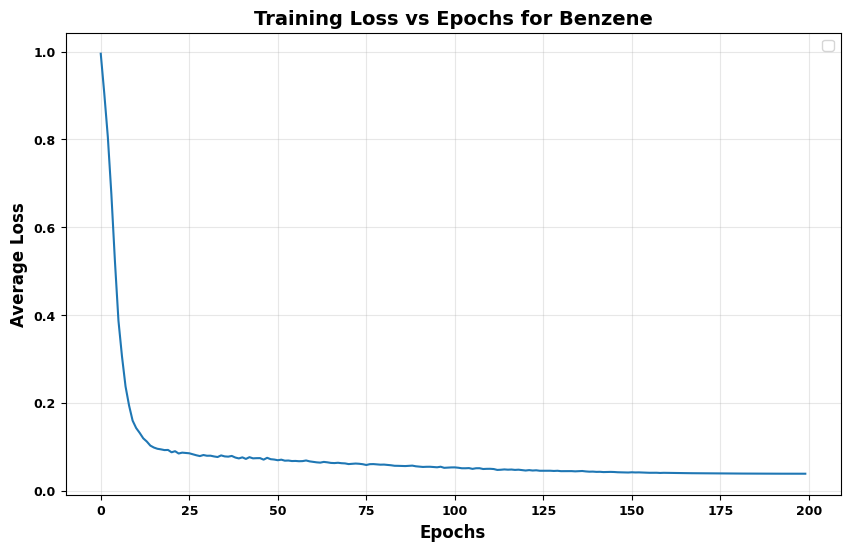

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), losses)
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Average Loss', fontsize=12, fontweight='bold')
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('REALTrain_loss_vs_epoch_benzene.png')
plt.title('Training Loss vs Epochs for Benzene', fontsize=14, fontweight='bold')
plt.show()

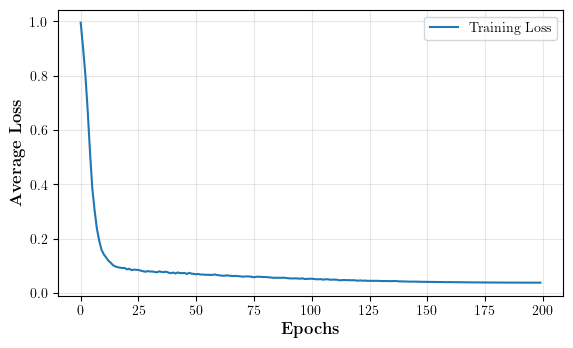

In [19]:
import matplotlib as mpl

# --- LaTeX-style plotting setup ---
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Function to match figure size to LaTeX text width
def set_size(width_pt, fraction=1):
    inches_per_pt = 1/72.27
    golden_ratio = (5**0.5 - 1)/2
    width_in = width_pt * inches_per_pt * fraction
    height_in = width_in * golden_ratio
    return (width_in, height_in)

# 426 pt ≈ typical LaTeX text width
fig = plt.figure(figsize=set_size(426))

# --- Your plot ---
plt.plot(losses, label='Training Loss')

plt.xlabel(r'\textbf{Epochs}')
plt.ylabel(r'\textbf{Average Loss}')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend()
plt.grid(True, alpha=0.3)

#plt.title(r'\textbf{Training Loss vs Epochs for Aspirin}', fontsize=14)

plt.tight_layout()

# Save as vector graphic for LaTeX
plt.savefig('2BTrain_loss_vs_epoch_aspirin.pdf')

plt.show()

In [14]:
model.eval()
with torch.no_grad():
    final_test_pred = model(X_test_t)
    final_test_loss = nn.MSELoss()
    loss = final_test_loss(final_test_pred, y_test_t)
print("final test loss:", float(loss))

pred_unnormalized = final_test_pred.numpy().squeeze() * std_y + mu_y
true_unnormalized = y_test_t.numpy().squeeze() * std_y + mu_y

final test loss: 0.1250755339860916


In [15]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(true_unnormalized, pred_unnormalized)
mae = mean_absolute_error(true_unnormalized, pred_unnormalized)
mse = mean_squared_error(true_unnormalized, pred_unnormalized)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")  
print(f"MAE: {mae:.4f}")      
print(f"RMSE: {rmse:.4f}")

R² Score: 0.8697
MAE: 0.6311
RMSE: 0.8377


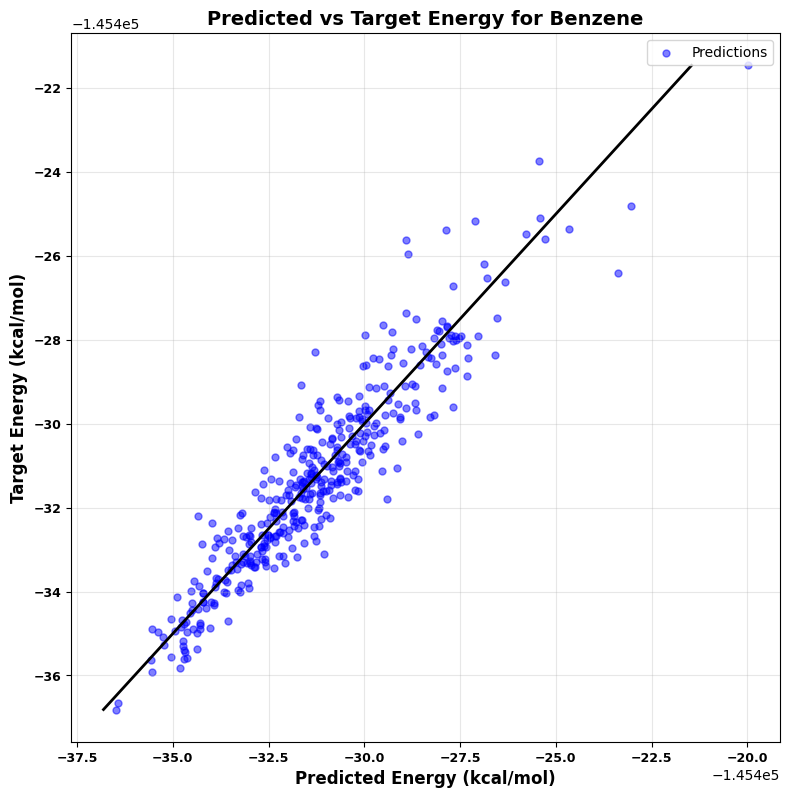

In [16]:
plt.figure(figsize=(8,8))
plt.scatter(pred_unnormalized, true_unnormalized, alpha=0.5, s=25, color='blue', label='Predictions')
plt.plot([true_unnormalized.min(), true_unnormalized.max()], 
         [true_unnormalized.min(), true_unnormalized.max()], 
         'k-', lw=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel('Predicted Energy (kcal/mol)', fontsize=12, fontweight='bold')
plt.ylabel('Target Energy (kcal/mol)', fontsize=12, fontweight='bold')
plt.xticks(fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('REALtarget_vs_predE_benzene.png')
plt.title('Predicted vs Target Energy for Benzene', fontsize=14, fontweight='bold')
plt.show()